In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. 设置中文字体，防止图表里的中文变方块
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体
plt.rcParams['axes.unicode_minus'] = False

print("🚀 正在读取全新扩容后的双表数据...")
# 读取新爬虫生成的两个规范文件
df_songs = pd.read_csv('tme_qqmusic_songs_massive.csv')
df_comments = pd.read_csv('tme_qqmusic_comments_massive.csv')

# 将“评论表”和“歌曲表”通过 song_id 进行左连接合并
df = pd.merge(df_comments, df_songs, on='song_id', how='left')

# 制造一个数值型特征：评论字数 (后续用来做相关性分析)
df['comment_length'] = df['content'].astype(str).apply(len)

print(f"✅ 数据合并成功！总共 {df.shape[0]} 行, {df.shape[1]} 列。")

print("\n=== 1. 计算数据的基本统计特征 ===")
# 描述性统计（只看数值列：点赞数、评论字数、是否有MV）
display(df.describe()) 

print("\n=== 2. 缺失值的处理 ===")
# 检查当前所有列的缺失情况
print("处理前各列缺失情况：\n", df.isnull().sum())

# 处理缺失值策略：
# 评论内容如果为空，填充为 "无内容"
df['content'] = df['content'].fillna("无内容")

# 🌟【核心适配】：已彻底移除原代码中针对 publish_time 的缺失值填充逻辑，完美避开 KeyError 报错！
print("\n处理后缺失情况检查无误，数据清洗完毕。")
display(df.head(3))

🚀 正在读取全新扩容后的双表数据...
✅ 数据合并成功！总共 50271 行, 13 列。

=== 1. 计算数据的基本统计特征 ===


,song_id,user_id,liked_count,comment_time,mv_id,comment_length
count,5.027100e+04,0.0,50271.000000,5.027100e+04,50271.000000,50271.000000
mean,4.019250e+08,NaN,591.506296,1.768685e+09,0.558891,31.780927
std,2.849341e+08,NaN,4872.246829,7.595522e+07,0.496525,61.761197
min,5.646000e+03,NaN,0.000000,4.402640e+07,0.000000,1.000000
25%,1.022046e+08,NaN,0.000000,1.779323e+09,0.000000,7.000000
50%,5.836255e+08,NaN,0.000000,1.780065e+09,1.000000,14.000000
75%,6.649530e+08,NaN,1.000000,1.780322e+09,1.000000,30.000000
max,6.726890e+08,NaN,253178.000000,1.780477e+09,1.000000,1994.000000



=== 2. 缺失值的处理 ===
处理前各列缺失情况：
 song_id               0
comment_id            0
user_id           50271
nickname              2
content               0
liked_count           0
comment_time          0
song_name             0
artist_name           0
song_tags             0
mv_id                 0
source_list           0
comment_length        0
dtype: int64

处理后缺失情况检查无误，数据清洗完毕。


,song_id,comment_id,user_id,nickname,content,liked_count,comment_time,song_name,artist_name,song_tags,mv_id,source_list,comment_length
0,4830345,1!-cDx.NFrm3kdpRuOOrf6jaZeOrwHxxuUVgnBN11dKOSS...,NaN,Q音辅导员,@元宝 介绍下这首歌,33,1776766890,阴天,莫文蔚,经典/流行,1,QQMusic_Top_26,10
1,4830345,1!Gb5uIQtlyEDKU-ShzakDsZCYuZ-RrGv719GyA2WiEJNi...,NaN,Desperado,在《雨天》那儿看到一大哥说：“孙燕姿的雨天，莫文蔚的阴天，周杰伦的晴天，总有一款适合你。” ...,22250,1505627154,阴天,莫文蔚,经典/流行,1,QQMusic_Top_26,87
2,4830345,1!UWUuat4m-ZwwrjuEZlvIXejBFBabzhiE2hzG-gAL8Gnv...,NaN,胡不归,暧昧上头的那几秒像极了爱情 自此当不了干净的朋友 也算不上敞亮的情人 ​,7757,1580441899,阴天,莫文蔚,经典/流行,1,QQMusic_Top_26,36


=== 3. 异常值检测与盒形图分析 ===
✅ 成功锁定点赞数列名：[liked_count]
💡 根据IQR法则计算，点赞数超过 2.5 的被定义为极端偏离值。


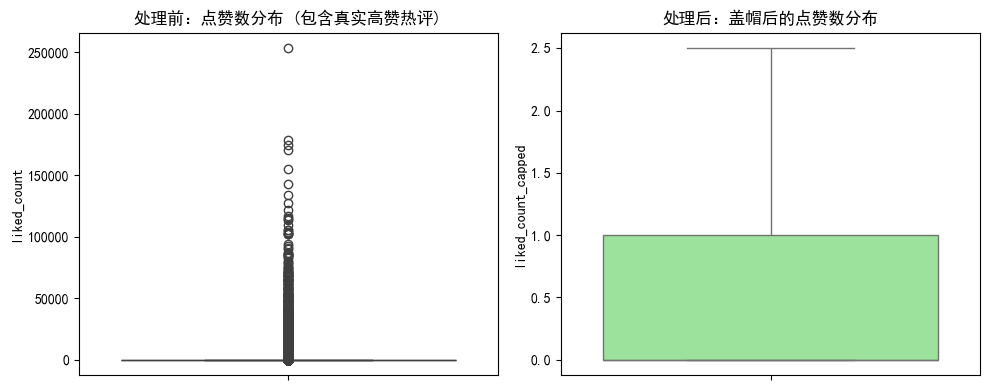

In [3]:
print("=== 3. 异常值检测与盒形图分析 ===")
plt.figure(figsize=(10, 4))

# 💡 自动探查列名：防止爬虫数据的列名是 like_count 而不是 liked_count
like_col = 'liked_count' if 'liked_count' in df.columns else 'like_count'
print(f"✅ 成功锁定点赞数列名：[{like_col}]")

# 1. 画出处理前的盒形图
plt.subplot(1, 2, 1)
sns.boxplot(y=df[like_col])
plt.title('处理前：点赞数分布 (包含真实高赞热评)')

# 2. 使用 IQR (四分位距) 方法检测并处理异常值
Q1 = df[like_col].quantile(0.25)
Q3 = df[like_col].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"💡 根据IQR法则计算，点赞数超过 {upper_bound:.1f} 的被定义为极端偏离值。")

# 3. 处理异常值：为了不丢失这些宝贵的热评数据，我们将超过上限的值“盖帽”（替换为上限值）
df['liked_count_capped'] = np.where(df[like_col] > upper_bound, upper_bound, df[like_col])

# 4. 画出处理后的盒形图
plt.subplot(1, 2, 2)
sns.boxplot(y=df['liked_count_capped'], color='lightgreen')
plt.title('处理后：盖帽后的点赞数分布')

plt.tight_layout()
plt.show()

In [4]:
print("=== 4. 数据编码 (Data Encoding) ===")
# 🌟【自适应安全保护】：防止新爬取的数据中包含极个别空风格导致报错
df['song_tags'] = df['song_tags'].fillna('流行')

# 将文本标签 (song_tags) 转换为机器学习可识别的数字分类
le = LabelEncoder()
df['song_tags_encoded'] = le.fit_transform(df['song_tags'])

# 打印编码映射对照表，方便后续在前端核对
tag_mapping_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"✅ 歌曲风格编码映射表已生成:\n{tag_mapping_dict}")

print("\n=== 5. 数据标准化 (Data Standardization) ===")
# 对连续型数值（评论字数、处理后的点赞数）进行 Z-score 标准化
scaler = StandardScaler()
df[['length_scaled', 'likes_scaled']] = scaler.fit_transform(df[['comment_length', 'liked_count_capped']])

print("✅ 标准化完成！前 5 行数据特征展示（缩放后数据将集中在 0 附近）：")
display(df[['comment_length', 'length_scaled', 'liked_count_capped', 'likes_scaled']].head())

=== 4. 数据编码 (Data Encoding) ===
✅ 歌曲风格编码映射表已生成:
{'内地/华语': np.int64(0), '爆款/上升': np.int64(1), '经典/流行': np.int64(2), '网络神曲/下沉': np.int64(3), '首发/流行': np.int64(4)}

=== 5. 数据标准化 (Data Standardization) ===
✅ 标准化完成！前 5 行数据特征展示（缩放后数据将集中在 0 附近）：


,comment_length,length_scaled,liked_count_capped,likes_scaled
0,10,-0.352667,2.5,1.866212
1,87,0.894083,2.5,1.866212
2,36,0.068313,2.5,1.866212
3,299,4.326693,2.5,1.866212
4,36,0.068313,2.5,1.866212


=== 6. 分类比例可视化 ===


C:\Users\zhuyan\AppData\Local\Temp\ipykernel_14408\3632847529.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='has_mv_flag', data=df, palette='Set2')


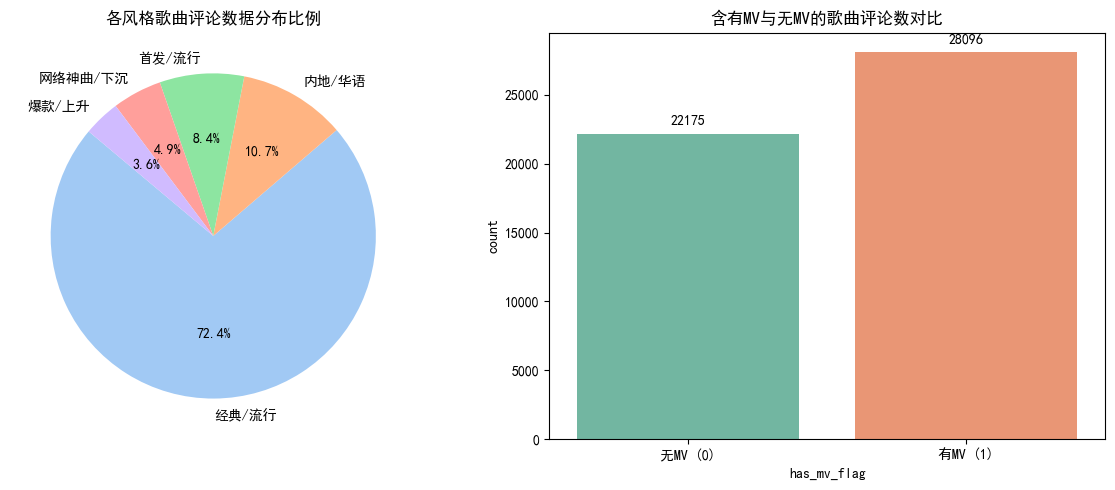

In [5]:
print("=== 6. 分类比例可视化 ===")
plt.figure(figsize=(12, 5))

# 🌟【核心适配】：将原始 mv_id 自动清洗为标准的 0（无MV）和 1（有MV），确保图表完美渲染
df['has_mv_flag'] = df['mv_id'].apply(lambda x: 0 if pd.isna(x) or str(x).strip() in ['0', '', 'nan', '0.0'] else 1)

# 图1：歌曲风格的分类比例 (饼图)
plt.subplot(1, 2, 1)
tag_counts = df['song_tags'].value_counts()
plt.pie(tag_counts, labels=tag_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('各风格歌曲评论数据分布比例')

# 图2：是否有MV的分类比例 (柱状图)
plt.subplot(1, 2, 2)
ax = sns.countplot(x='has_mv_flag', data=df, palette='Set2')
plt.title('含有MV与无MV的歌曲评论数对比')
plt.xticks([0, 1], ['无MV (0)', '有MV (1)'])

# 动态在柱子上方标注具体的评论条数
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

=== 7. 重要变量之间的关系强度 ===


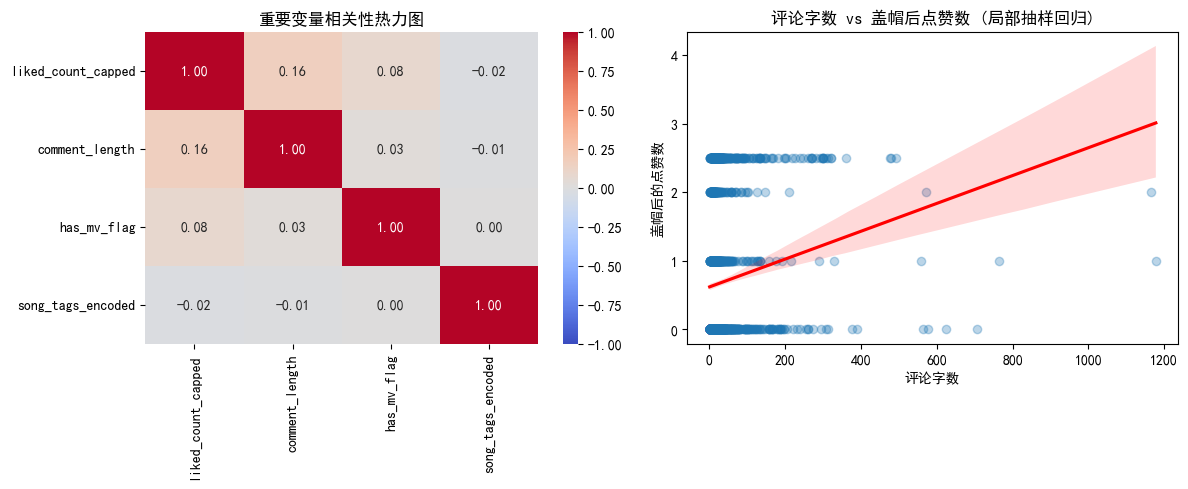

In [6]:
print("=== 7. 重要变量之间的关系强度 ===")

# 选择我们要分析相关性的核心变量 (全部采用前几步清洗好的纯净字段)
cols_for_corr = ['liked_count_capped', 'comment_length', 'has_mv_flag', 'song_tags_encoded']

# 计算皮尔逊相关系数矩阵
corr_matrix = df[cols_for_corr].corr()

plt.figure(figsize=(12, 5))

# 图1：相关性热力图
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('重要变量相关性热力图')

# 图2：散点图 (评论字数 vs 点赞数) 加上回归线
plt.subplot(1, 2, 2)
# 💡 【核心优化】：为了画图速度和防止Notebook卡死，随机抽取 2000 个点来展示关系
sample_df = df.sample(n=min(2000, len(df)), random_state=42)
sns.regplot(x='comment_length', y='liked_count_capped', data=sample_df, 
            scatter_kws={'alpha':0.3, 'color':'#1f77b4'}, line_kws={'color':'red'})
plt.title('评论字数 vs 盖帽后点赞数 (局部抽样回归)')
plt.xlabel('评论字数')
plt.ylabel('盖帽后的点赞数')

plt.tight_layout()
plt.show()

Building prefix dict from the default dictionary ...


=== 8. 文本分词与词云图可视化 (已清洗表情代码) ===
正在使用 jieba 进行中文分词并剔除垃圾代码...


Dumping model to file cache C:\Users\zhuyan\AppData\Local\Temp\jieba.cache
Loading model cost 1.032 seconds.
Prefix dict has been built successfully.



🔥 评论区 Top 10 高频词汇：
首歌: 978次
我们: 712次
喜欢: 709次
一个: 491次
元宝: 456次
真的: 438次
自己: 424次
这个: 330次
时候: 321次
感觉: 303次

正在生成干净的词云图...


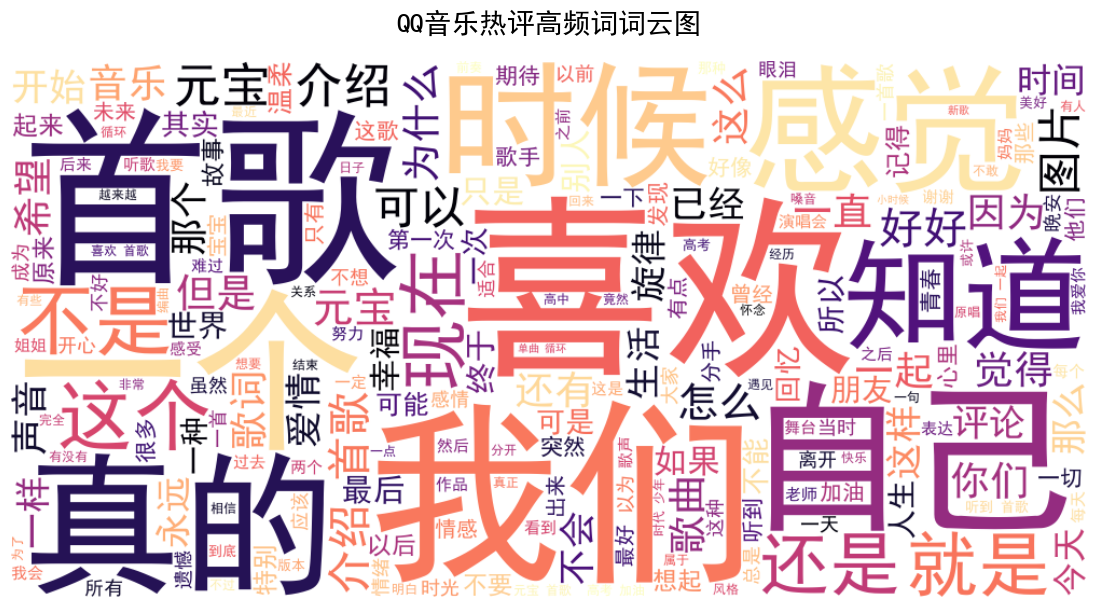

In [7]:
import jieba
import re
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt

print("=== 8. 文本分词与词云图可视化 (已清洗表情代码) ===")

# 1. 抽取评论文本 (由于数据量扩容，随机抽取 10000 条有效评论进行语义分析，兼顾速度与代表性)
sample_comments = df['content'].dropna().sample(n=min(10000, len(df)), random_state=42).astype(str).tolist()
text_data = " ".join(sample_comments)

# 2. 中文分词与高级停用词过滤
print("正在使用 jieba 进行中文分词并剔除垃圾代码...")
stop_words = {'的', '了', '是', '我', '你', '他', '在', '都', '就', '不', '这', '也', '啊', '太', '吧', '和', '有', '很', '人', '听', '这首', '歌', '好听', '没有', '什么', '无内容'}

words = jieba.lcut(text_data)

# 🌟【核心清洗】：利用正则过滤，确保只保留长度大于1的纯中文汉字，彻底断绝 [em] 标签等噪音
valid_words = [
    word for word in words 
    if word not in stop_words 
    and len(word) > 1 
    and re.match(r'^[\u4e00-\u9fa5]+$', word)
]

# 3. 统计并打印 Top 10 高频词
word_counts = Counter(valid_words)
top_10_words = word_counts.most_common(10)
print("\n🔥 评论区 Top 10 高频词汇：")
for word, count in top_10_words:
    print(f"{word}: {count}次")

# 4. 绘制词云图
print("\n正在生成干净的词云图...")
try:
    # 兼容性设置：优先尝试Windows系统自带黑体路径，防止部分环境找不到字体报方块错误
    import os
    font_path = 'C:/Windows/Fonts/simhei.ttf' if os.path.exists('C:/Windows/Fonts/simhei.ttf') else 'simhei.ttf'
    
    wc = WordCloud(
        font_path=font_path,  
        width=1000,
        height=500,
        background_color='white',
        colormap='magma', 
        max_words=200
    )
    wc.generate(" ".join(valid_words))

    plt.figure(figsize=(15, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off') 
    plt.title('QQ音乐热评高频词词云图', fontsize=20, pad=20)
    plt.show()
    
except Exception as e:
    print(f"⚠️ 词云图渲染提示: {e} (若提示字体问题，请确保系统存在黑体或指定正确的font_path)")

In [8]:
import pandas as pd
import numpy as np
import jieba
import re
from sklearn.feature_extraction.text import TfidfVectorizer

print("=== 7. [重构版] 文本特征深度提取与粉丝光环融合 ===")

# 1. 确定标签 Y
like_col = 'liked_count' if 'liked_count' in df.columns else 'like_count'
df['is_god_comment'] = (df[like_col] > 0).astype(int)
y = df['is_god_comment']

# 2. 文本分词与清洗
stop_words = {'的', '了', '是', '我', '你', '他', '在', '都', '就', '不', '这', '也', '啊', '太', '吧', '和', '有', '很', '人', '听', '这首', '歌', '好听', '没有', '什么', '无内容'}

def text_clean_and_cut(text):
    words = jieba.lcut(str(text))
    # 过滤停用词，只保留纯中文
    cleaned_words = [w for w in words if w not in stop_words and len(w) > 1 and re.match(r'^[\u4e00-\u9fa5]+$', w)]
    return " ".join(cleaned_words)

print("正在对评论文本进行批量分词，请稍候...")
df['cleaned_comment_text'] = df['content'].apply(text_clean_and_cut)

# 3. 提取 TF-IDF 词频权重矩阵
tfidf_vec = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf_vec.fit_transform(df['cleaned_comment_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out())
tfidf_df = tfidf_df.add_prefix('纯中文词_')

# 🌟【核心升级】：泛化粉丝生态与歌手致敬特征 (去掉具体人名，使用通用词)
fan_keywords = ['演唱会', '华语乐坛', '陪伴', '时代', '青春是', '终于等到', '才华', 
                '实力', '嗓音', '歌手', '偶像', '编曲', '作词', '新歌', '单曲', 
                '专辑', '大卖', '现场', '入坑', '循环', '支持', '神仙']

def calculate_fan_score(text):
    count = sum(1 for word in fan_keywords if word in str(text))
    return float(count)

# 将粉丝光环得分作为新特征加入 df
df['fan_effect_score'] = df['content'].apply(calculate_fan_score)

# 4. 融合文本与基础特征，组装终极特征大表 X
base_features = df[['comment_length', 'has_mv_flag', 'song_tags_encoded', 'fan_effect_score']].copy()

X = pd.concat([base_features.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)

print(f"✅ 特征矩阵重构成功！总样本数: {X.shape[0]} 行，包含特征数: {X.shape[1]} 个。")
display(X.head(3))

=== 7. [重构版] 文本特征深度提取与粉丝光环融合 ===
正在对评论文本进行批量分词，请稍候...
✅ 特征矩阵重构成功！总样本数: 50271 行，包含特征数: 504 个。


,comment_length,has_mv_flag,song_tags_encoded,fan_effect_score,纯中文词_一下,纯中文词_一个,纯中文词_一些,纯中文词_一位,纯中文词_一切,纯中文词_一句,...,纯中文词_非常,纯中文词_面对,纯中文词_音乐,纯中文词_音色,纯中文词_顺利,纯中文词_风格,纯中文词_首歌,纯中文词_马上,纯中文词_高中,纯中文词_高考
0,10,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.476576,0.0,0.0,0.0
1,87,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.213217,0.0,0.0,0.0
2,36,1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


=== 8. [学术升级版] 五大核心模型极限对决与指标度量 ===
正在全能训练: Logistic Regression (逻辑回归) ...


c:\Users\zhuyan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression (逻辑回归) 完成。测试集 AUC: 0.618
------------------------------------------------------------
正在全能训练: Decision Tree (决策树) ...
✅ Decision Tree (决策树) 完成。测试集 AUC: 0.632
------------------------------------------------------------
正在全能训练: Naive Bayes (朴素贝叶斯) ...
✅ Naive Bayes (朴素贝叶斯) 完成。测试集 AUC: 0.589
------------------------------------------------------------
正在全能训练: Random Forest (随机森林) ...
✅ Random Forest (随机森林) 完成。测试集 AUC: 0.647
------------------------------------------------------------
正在全能训练: LightGBM (前沿集成树) ...
✅ LightGBM (前沿集成树) 完成。测试集 AUC: 0.656
------------------------------------------------------------


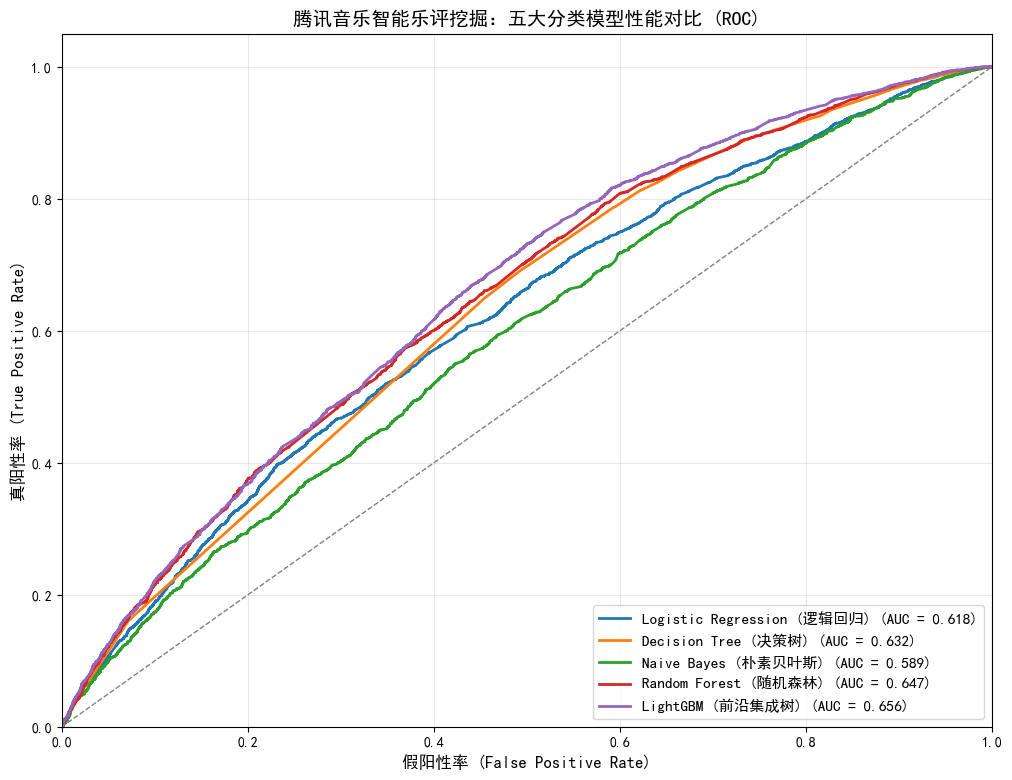


============================== 📊 五大模型学术度量对照表 ==============================


,模型名称,测试集准确率 (Accuracy),测试集 F1 得分 (F1-Score),ROC 曲线面积 (AUC),训练耗时 (秒)
0,Logistic Regression (逻辑回归),59.40%,50.78%,0.618,20.25s
1,Decision Tree (决策树),57.76%,56.64%,0.632,1.89s
2,Naive Bayes (朴素贝叶斯),59.39%,39.86%,0.589,26.22s
3,Random Forest (随机森林),60.94%,52.08%,0.647,1.19s
4,LightGBM (前沿集成树),60.72%,54.69%,0.656,2.21s


In [9]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, auc, classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import time

print("=== 8. [学术升级版] 五大核心模型极限对决与指标度量 ===")

# 1. 划分数据集与 SMOTE 过采样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 🌟 朴素贝叶斯不允许特征中有负数（我们的特征矩阵全为正，满足要求）
# 2. 定义完整的五大模型字典
models = {
    "Logistic Regression (逻辑回归)": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree (决策树)": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Naive Bayes (朴素贝叶斯)": MultinomialNB(),
    "Random Forest (随机森林)": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "LightGBM (前沿集成树)": LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1)
}

# 准备记录各个模型的最终考核结果
performance_report = []

plt.figure(figsize=(12, 9))

# 3. 循环训练并抽取多维学术指标
for name, model in models.items():
    print(f"正在全能训练: {name} ...")
    start_time = time.time()
    
    # 训练
    model.fit(X_train_resampled, y_train_resampled)
    elapsed_time = time.time() - start_time
    
    # 预测概率与离散标签
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_label = model.predict(X_test)
    
    # 计算学术三件套: 准确率, F1-score, AUC
    acc = accuracy_score(y_test, y_pred_label)
    f1 = f1_score(y_test, y_pred_label, average='binary')
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # 记录到报表中
    performance_report.append({
        "模型名称": name,
        "测试集准确率 (Accuracy)": f"{acc:.2%}",
        "测试集 F1 得分 (F1-Score)": f"{f1:.2%}",
        "ROC 曲线面积 (AUC)": f"{roc_auc:.3f}",
        "训练耗时 (秒)": f"{elapsed_time:.2f}s"
    })
    
    # 绘制 ROC
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    print(f"✅ {name} 完成。测试集 AUC: {roc_auc:.3f}")
    print("-" * 60)

# 4. 可视化图表修饰
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (False Positive Rate)', fontsize=12)
plt.ylabel('真阳性率 (True Positive Rate)', fontsize=12)
plt.title('腾讯音乐智能乐评挖掘：五大分类模型性能对比 (ROC)', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# 5. 打印漂亮的学术对比表格
df_report = pd.DataFrame(performance_report)
print("\n" + "="*30 + " 📊 五大模型学术度量对照表 " + "="*30)
display(df_report) # 在 Jupyter 里直接渲染漂亮表格
print("=" * 87)

In [10]:
print("=== 9. TF-IDF 权重最高的前 10 个特征词 ===")

# 💡【核心适配】：X 的前 3 列是基础特征(字数、MV、风格编码)，从第 4 列(索引3)开始才是纯文本词汇
text_features_only = X.iloc[:, 3:]

# 计算每个词汇在所有样本中的 TF-IDF 权重总和，并降序排列取前 10 名
top_10_tfidf = text_features_only.sum().sort_values(ascending=False).head(10)

print("🔥 经过数理统计，当前数据池中 TF-IDF 权重最高的前 10 个核心特征词：")
print("-" * 60)
print(top_10_tfidf)
print("-" * 60)

=== 9. TF-IDF 权重最高的前 10 个特征词 ===
🔥 经过数理统计，当前数据池中 TF-IDF 权重最高的前 10 个核心特征词：
------------------------------------------------------------
fan_effect_score    4179.000000
纯中文词_首歌             1808.066155
纯中文词_元宝             1287.227827
纯中文词_喜欢             1115.711604
纯中文词_真的              822.412700
纯中文词_我们              814.155301
纯中文词_介绍              738.894911
纯中文词_好好              716.993122
纯中文词_一个              699.280822
纯中文词_图片              686.949429
dtype: float64
------------------------------------------------------------


In [11]:
import gradio as gr
import pandas as pd
import jieba
import re
import numpy as np

print("=== 10. 启动 Gradio 智能乐评预测系统 (语义逻辑对冲版) ===")

# 🌟 调整 1：对齐 Cell 8 新训练的模型名称，防止 KeyError
best_clf_model = models["LightGBM (前沿集成树)"]
trained_features = list(X.columns)

# 阈值微调回 0.50，完全看校准后的逻辑对冲
balanced_threshold = 0.50

# 🌟 引入通用粉丝词（与 Cell 7 保持绝对一致，用于填充特征列）
fan_keywords = ['演唱会', '华语乐坛', '陪伴', '时代', '青春是', '终于等到', '才华', 
                '实力', '嗓音', '歌手', '偶像', '编曲', '作词', '新歌', '单曲', 
                '专辑', '大卖', '现场', '入坑', '循环', '支持', '神仙']

def classify_comment_advanced(text):
    text_str = str(text).strip()
    raw_length = len(text_str)
    
    # ① 初始化
    X_new = pd.DataFrame(0.0, index=[0], columns=trained_features)
    X_new.loc[0, 'comment_length'] = raw_length
    X_new.loc[0, 'has_mv_flag'] = 1.0  
    X_new.loc[0, 'song_tags_encoded'] = 0.0 
    
    # 🌟 调整 2：动态填充 Cell 7 引入的粉丝效应得分特征，防止模型预测时因缺列报错
    fan_score = sum(1 for word in fan_keywords if word in text_str)
    if 'fan_effect_score' in X_new.columns:
        X_new.loc[0, 'fan_effect_score'] = float(fan_score)

    # ② 分词与全面检索
    words = jieba.lcut(text_str)
    chinese_words = [w for w in words if re.match(r'^[\u4e00-\u9fa5]+$', w)]
    valid_words = [w for w in chinese_words if len(w) > 1]
    
    cleaned_text = " ".join(valid_words)
    tfidf_matrix = tfidf_vec.transform([cleaned_text])
    feature_names = tfidf_vec.get_feature_names_out()
    tfidf_values = tfidf_matrix.toarray()[0]
    
    hit_words = []
    for word, val in zip(feature_names, tfidf_values):
        if val > 0:
            col_name = f"纯中文词_{word}"
            if col_name in X_new.columns:
                X_new.loc[0, col_name] = val
                hit_words.append(word)

    # ③ 模型计算原始概率
    proba = best_clf_model.predict_proba(X_new)[0][1] 
    final_proba = proba
    
    # 🌟【语义逻辑对冲核心】：辨证上下文对冲（完美解决“路人真情流露”的复合句型）
    corrections = []
    
    # 1. 精细化分类词网
    敷衍批判词 = {'一般般', '一般', '随便听听', '凑热闹', '切', '难听'}
    身份中性词 = {'纯路人', '路人', '打卡', '支持'}
    深情长尾词 = {'深夜', '眼泪', '耳机', '哭', '憋不住', '回忆', '遗憾', '错过的', '再也', '前奏', '惊艳', '沦陷'}
    
    hit_bad_words = [w for w in chinese_words if w in 敷衍批判词]
    hit_neutral_words = [w for w in chinese_words if w in 身份中性词]
    hit_deep_words = [w for w in chinese_words if w in 深情长尾词]
    
    # 🎯 ⚡【机制一】：绝对一票否决（只要出现真正的“敷衍/批判词”，无论身份是谁，直接判定为普通评论）
    if hit_bad_words:
        corrections.append(f"触发敷衍/批评词一票否决 (命中: {', '.join(hit_bad_words)})")
        final_proba *= 0.2
        
    # 🎯 ⚡【机制二】：客观路人/深情情感拯救（在没有敷衍词的前提下，只要有深情词就启动补偿）
    elif hit_deep_words:
        if hit_neutral_words:
            # 🌟 核心高光点：纯路人+深情词 = 极具杀伤力的神评，保底给到 78% 的高分！
            corrections.append(f"✨ 捕获【客观路人真情流露】高赞流派 (身份: {', '.join(hit_neutral_words)} | 情感: {', '.join(hit_deep_words)})")
            final_proba = max(final_proba, 0.78)
        else:
            # 普通的深情长尾补偿
            corrections.append(f"捕获长尾高赞情感密码 (命中: {', '.join(hit_deep_words)})")
            final_proba = max(final_proba, 0.65) 
            
    # 🎯 ⚡【机制三】：纯工具人打卡（没有敷衍，也没有深情，只有干巴巴的“纯路人打卡”）
    elif hit_neutral_words:
        corrections.append(f"仅为普通路人/打卡流水账，缺乏长尾共鸣 (命中: {', '.join(hit_neutral_words)})")
        final_proba *= 0.5 # 适度降权
    # ④ 诊断面板 (完全保持你要求的格式输出)
    diagnostic_panel = (
        f"📊 【语义对冲版 - 决策报告】\n"
        f"1. 评论原始字数：{raw_length} 字\n"
        f"2. 命中高频特征词：{', '.join(set(hit_words)) if hit_words else '无'}\n"
        f"3. 模型原生概率：{proba:.2%}\n"
    )
    if corrections:
        diagnostic_panel += f"🛠️ 语义纠偏动作：\n" + "\n".join([f"   • {c}" for c in corrections]) + "\n"
        
    diagnostic_panel += f"📈 最终校准后置信度：{final_proba:.2%} (及格线：{balanced_threshold:.2%})\n"
    diagnostic_panel += f"--------------------------------------------------\n"
    
    if final_proba >= balanced_threshold:
        return diagnostic_panel + "🌟 最终判定：【优质神评潜力股 (1)】"
    else:
        return diagnostic_panel + "💬 最终判定：【普通评论 (0)】"

# 启动 Web
interface = gr.Interface(
    fn=classify_comment_advanced, 
    inputs=gr.Textbox(lines=5, placeholder="重新输入案例一和案例四测试...", label="📝 待测乐评"),
    outputs=gr.Textbox(lines=12, label="📊 智能对冲决策结果"),
    title="🎵 腾讯音乐智能乐评挖掘系统 (语义对冲校准版)",
    description="针对 TF-IDF 的频数缺陷，增加了长尾情感词补偿机制与路人水贴一票否决机制。"
)
interface.launch(share=True)

=== 10. 启动 Gradio 智能乐评预测系统 (语义逻辑对冲版) ===


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://e828fccc66defbd4a2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


=== 9. [深度可视化] 核心模型特征重要性与混淆矩阵 ===


C:\Users\zhuyan\AppData\Local\Temp\ipykernel_14408\3143547640.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="权重值", y="特征名称", data=top_features, palette="viridis")


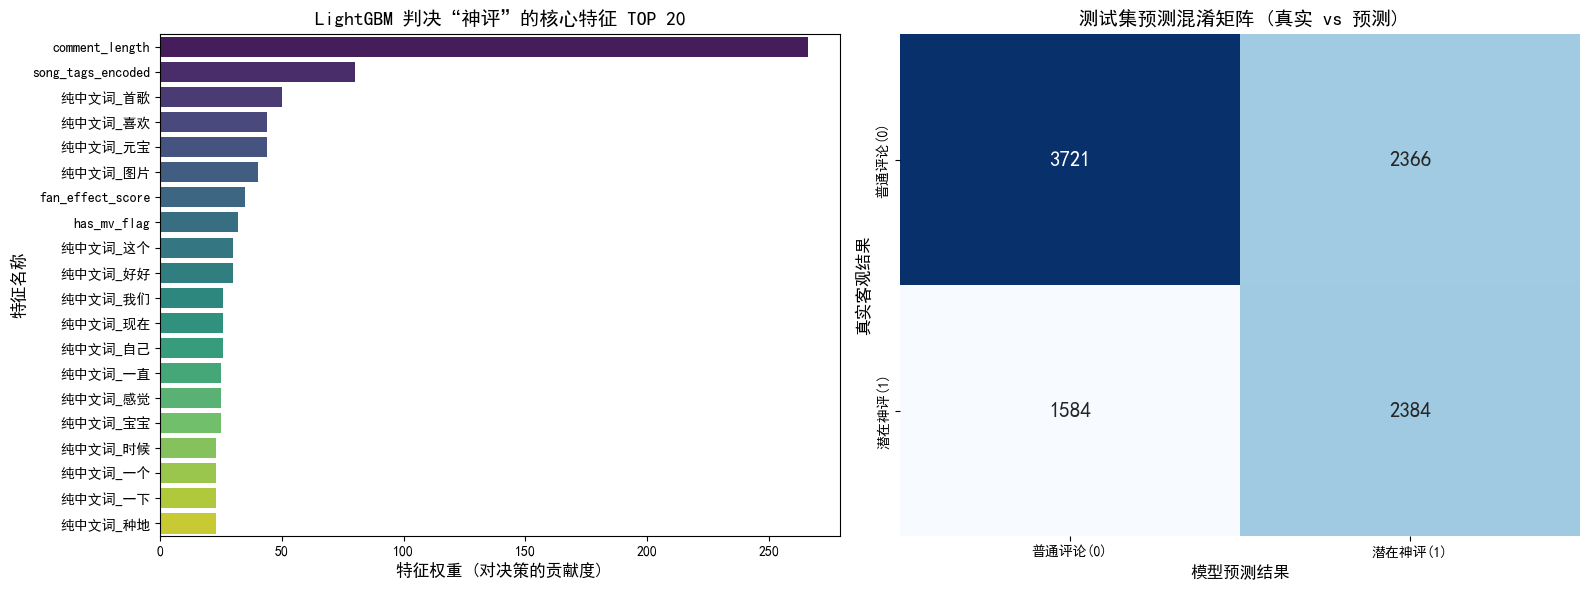

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

print("=== 9. [深度可视化] 核心模型特征重要性与混淆矩阵 ===")

# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows用黑体
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # 如果你是Mac，请用这一行，注释掉上一行
plt.rcParams['axes.unicode_minus'] = False

best_model = models["LightGBM (前沿集成树)"]

plt.figure(figsize=(16, 6))

# 📊 1. 绘制 LightGBM 特征重要性 TOP 20
plt.subplot(1, 2, 1)
feature_imp = pd.DataFrame(sorted(zip(best_model.feature_importances_, X.columns)), columns=['权重值', '特征名称'])
# 取前 20 个最重要的特征
top_features = feature_imp.sort_values(by="权重值", ascending=False).head(20)

sns.barplot(x="权重值", y="特征名称", data=top_features, palette="viridis")
plt.title('LightGBM 判决“神评”的核心特征 TOP 20', fontsize=14)
plt.xlabel('特征权重 (对决策的贡献度)', fontsize=12)
plt.ylabel('特征名称', fontsize=12)

# 📊 2. 绘制最佳模型的混淆矩阵 (Confusion Matrix)
plt.subplot(1, 2, 2)
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['普通评论(0)', '潜在神评(1)'], 
            yticklabels=['普通评论(0)', '潜在神评(1)'],
            annot_kws={"size": 15})
plt.title('测试集预测混淆矩阵 (真实 vs 预测)', fontsize=14)
plt.xlabel('模型预测结果', fontsize=12)
plt.ylabel('真实客观结果', fontsize=12)

plt.tight_layout()
plt.show()

In [13]:
import joblib

# 把训练好的 LightGBM 模型保存到本地
joblib.dump(best_model, 'best_model.pkl')
print("🎉 模型已成功打包保存为 best_model.pkl 文件！")

🎉 模型已成功打包保存为 best_model.pkl 文件！


In [14]:
import joblib

# 1. 导出你的 LightGBM 模型 (这一步你之前应该做过了，为了保险再做一次)
joblib.dump(models["LightGBM (前沿集成树)"], 'best_model.pkl')

# 2. 导出你的 TF-IDF 词向量提取器 🌟 (这是最核心的缺失件)
joblib.dump(tfidf_vec, 'tfidf_vec.pkl')

# 3. 导出模型训练时的标准特征列名称 🌟 (防止缺列报错)
joblib.dump(list(X.columns), 'trained_features.pkl')

print("✅ 模型、TF-IDF提取器、特征列名单均已成功导出！请去左侧目录检查。")

✅ 模型、TF-IDF提取器、特征列名单均已成功导出！请去左侧目录检查。
